Thermal Diffusivity = 7.692307692307692e-06
Fuel Elements = 247


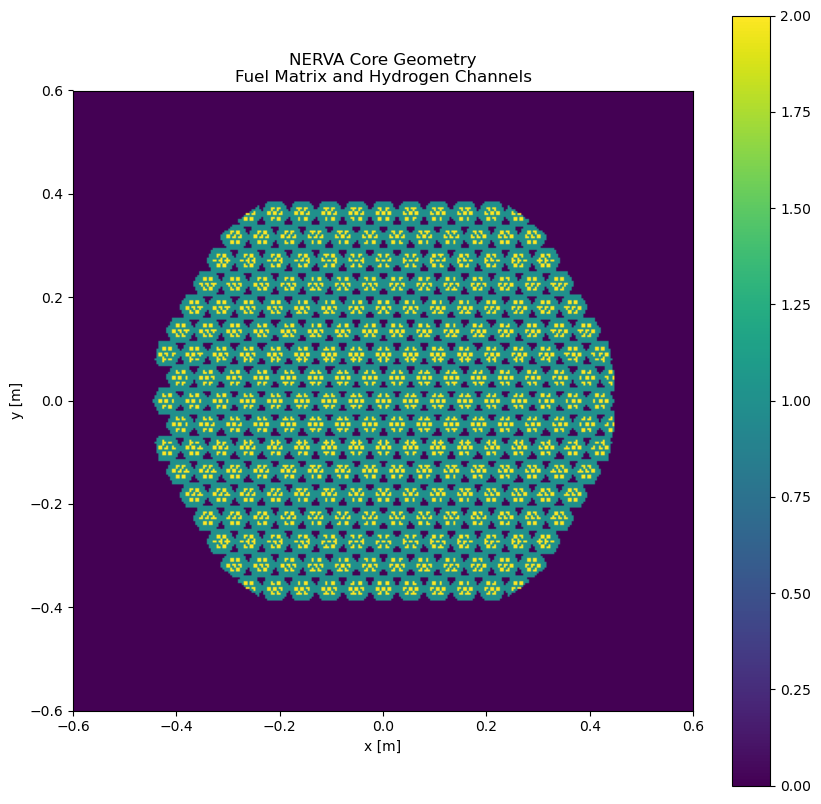

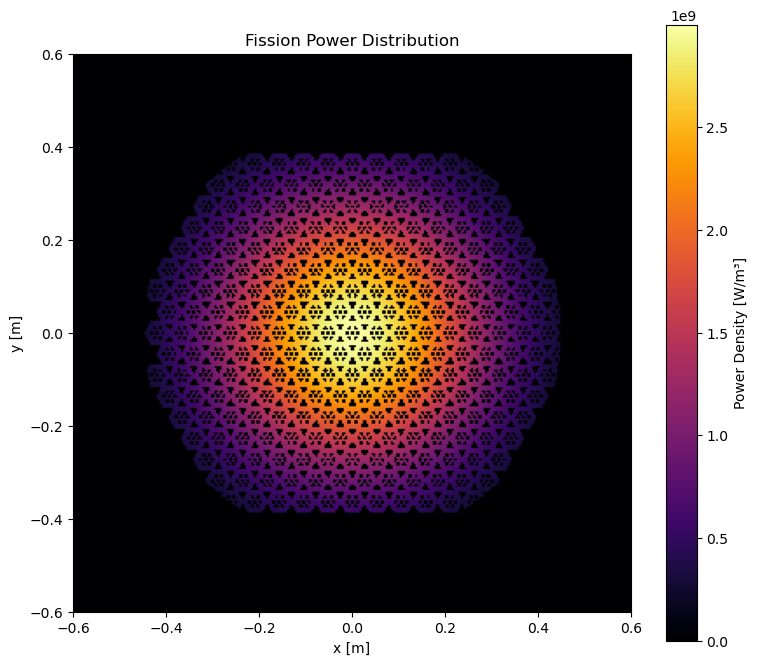

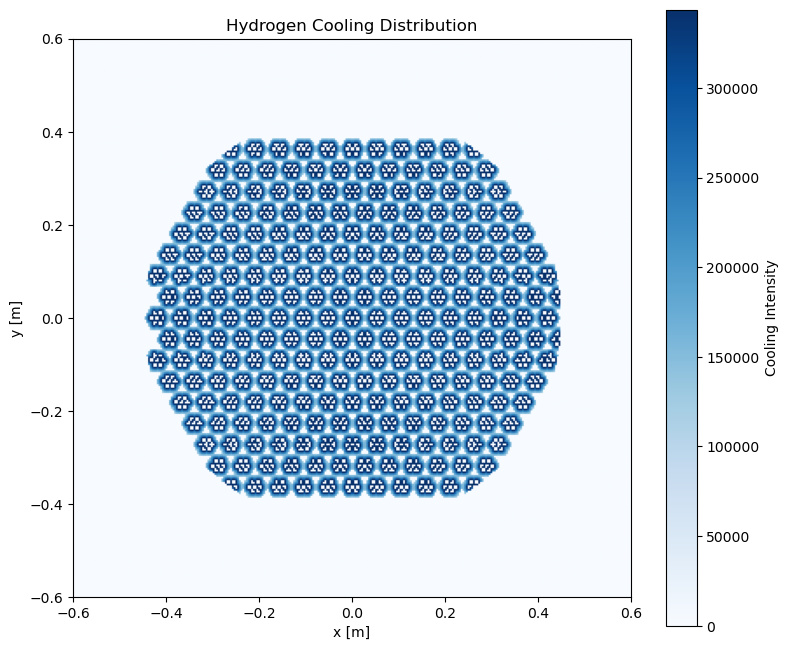

Step     0 | Tmax = 301.5 K
Step   500 | Tmax = 1039.7 K
Step  1000 | Tmax = 1688.0 K
Step  1500 | Tmax = 2221.7 K
Step  2000 | Tmax = 2648.1 K

Part 1 completed successfully.
Stored snapshots = 100


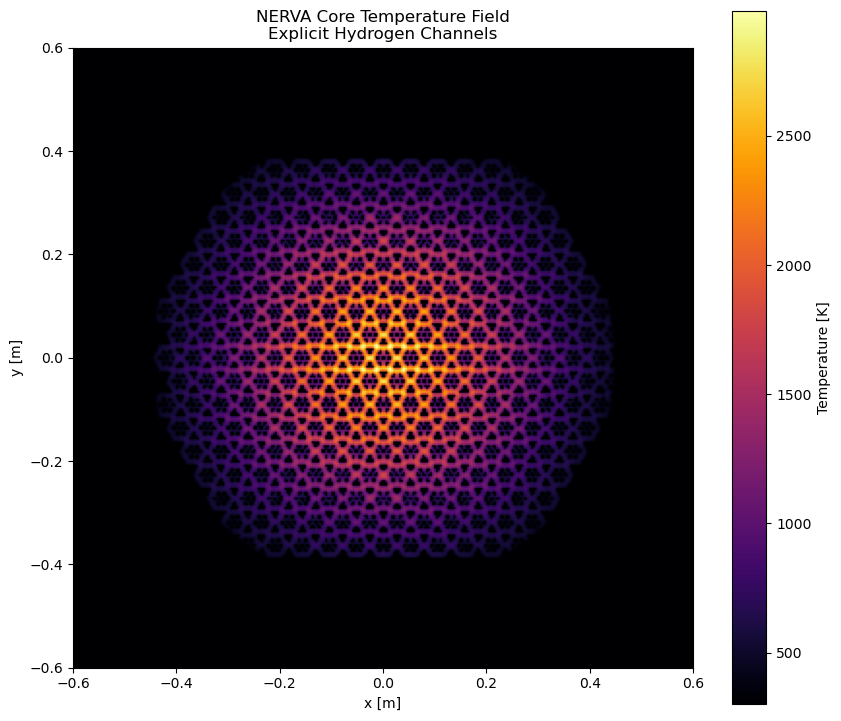


Ready for PART 2
Next: Thermal Power, H2 Exit Temperature, Isp and MP4


In [1]:
# ================================================================
# NUCLEAR THERMAL ROCKET (NERVA)
# ADVANCED 2D HEXAGONAL CORE SIMULATION
#
# PART 1 OF 2
#
# Features:
# - Explicit hexagonal fuel element geometry
# - Hydrogen cooling channels
# - UC-ZrC fuel matrix
# - Fission power generation
# - 2D heat conduction
# - Realistic NERVA-like temperature maps
#
# Part 2 will add:
# - H2 outlet temperature
# - Thermal power calculation
# - Thrust calculation
# - Specific impulse
# - MP4 animation
# - Engineering report
#
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

from scipy.ndimage import distance_transform_edt
from matplotlib.path import Path

# ================================================================
# CORE GEOMETRY
# ================================================================

Nx = 320
Ny = 320

Lx = 1.2
Ly = 1.2

dx = Lx/Nx
dy = Ly/Ny

x = np.linspace(-Lx/2,Lx/2,Nx)
y = np.linspace(-Ly/2,Ly/2,Ny)

X,Y = np.meshgrid(x,y)

# ================================================================
# NERVA CORE PARAMETERS
# ================================================================

core_radius = 0.45

fuel_element_flat = 0.05

channel_radius = 0.004

channels_per_element = 7

# ================================================================
# MATERIAL PROPERTIES
# ================================================================

rho = 13000.0
cp = 300.0
k = 30.0

alpha = k/(rho*cp)

print("Thermal Diffusivity =",alpha)

# ================================================================
# INITIAL TEMPERATURE
# ================================================================

Tinlet = 300.0

T = np.ones((Ny,Nx))*Tinlet

# ================================================================
# FUEL ELEMENT GENERATION
# ================================================================

fuel_mask = np.zeros((Ny,Nx),dtype=bool)

channel_mask = np.zeros((Ny,Nx),dtype=bool)

# ================================================================
# HEXAGON FUNCTION
# ================================================================

def create_hexagon(cx,cy,r):

    angles = np.linspace(
        0,
        2*np.pi,
        7
    )[:-1]

    vx = cx + r*np.cos(angles)
    vy = cy + r*np.sin(angles)

    vertices = np.column_stack([vx,vy])

    return Path(vertices)

# ================================================================
# GENERATE HEXAGONAL LATTICE
# ================================================================

pitch = fuel_element_flat*1.05

nring = 8

centers = []

for row in range(-nring,nring+1):

    for col in range(-nring,nring+1):

        cx = pitch*(col + 0.5*(row&1))

        cy = row*pitch*np.sqrt(3)/2

        if np.sqrt(cx**2+cy**2) < core_radius:

            centers.append((cx,cy))

print("Fuel Elements =",len(centers))

# ================================================================
# BUILD FUEL ELEMENTS
# ================================================================

for cx,cy in centers:

    hexagon = create_hexagon(
        cx,
        cy,
        fuel_element_flat/np.sqrt(3)
    )

    pts = np.column_stack(
        (
            X.ravel(),
            Y.ravel()
        )
    )

    inside = hexagon.contains_points(pts)

    inside = inside.reshape((Ny,Nx))

    fuel_mask |= inside

# ================================================================
# HYDROGEN CHANNELS
# ================================================================

for cx,cy in centers:

    offsets = [

        (0,0),

        (0.012,0),

        (-0.012,0),

        (0.006,0.010),

        (0.006,-0.010),

        (-0.006,0.010),

        (-0.006,-0.010)

    ]

    for ox,oy in offsets:

        r = np.sqrt(
            (X-(cx+ox))**2
            +
            (Y-(cy+oy))**2
        )

        channel_mask |= (
            r < channel_radius
        )

# ================================================================
# FUEL REGION
# ================================================================

fuel_mask &= ~channel_mask

# ================================================================
# CORE MASK
# ================================================================

core_mask = (
    np.sqrt(X**2+Y**2)
    <
    core_radius
)

fuel_mask &= core_mask

channel_mask &= core_mask

# ================================================================
# VISUALIZATION OF GEOMETRY
# ================================================================

plt.figure(figsize=(10,10))

geom = np.zeros((Ny,Nx))

geom[fuel_mask] = 1
geom[channel_mask] = 2

plt.imshow(
    geom,
    origin='lower',
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    cmap='viridis'
)

plt.title(
    'NERVA Core Geometry\n'
    'Fuel Matrix and Hydrogen Channels'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.colorbar()

plt.show()

# ================================================================
# FISSION POWER DISTRIBUTION
# ================================================================

R = np.sqrt(X**2+Y**2)

peak_power_density = 3e9

Q = (
    peak_power_density
    *
    np.exp(
        -(R/(0.65*core_radius))**2
    )
)

Q *= fuel_mask

# ================================================================
# POWER MAP
# ================================================================

plt.figure(figsize=(9,8))

plt.imshow(
    Q,
    origin='lower',
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    cmap='inferno'
)

plt.colorbar(
    label='Power Density [W/m³]'
)

plt.title(
    'Fission Power Distribution'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.show()

# ================================================================
# DISTANCE TO CHANNELS
# ================================================================
#
# Used to model explicit cooling
#
# Every fuel cell "feels"
# the nearby hydrogen channels.
#
# ================================================================

distance_to_channel = distance_transform_edt(
    ~channel_mask
)

distance_to_channel *= dx

# ================================================================
# EFFECTIVE COOLING FIELD
# ================================================================

h0 = 5e5

cooling_field = (
    h0
    *
    np.exp(
        -distance_to_channel/0.01
    )
)

cooling_field *= fuel_mask

# ================================================================
# VISUALIZE COOLING INTENSITY
# ================================================================

plt.figure(figsize=(9,8))

plt.imshow(
    cooling_field,
    origin='lower',
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    cmap='Blues'
)

plt.colorbar(
    label='Cooling Intensity'
)

plt.title(
    'Hydrogen Cooling Distribution'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.show()

# ================================================================
# TRANSIENT SOLVER
# ================================================================

dt = 0.002

steps = 2500

snapshots = []

# ================================================================
# MAIN TIME LOOP
# ================================================================

for n in range(steps):

    Tn = T.copy()

    lap = (

        (Tn[1:-1,2:]
        -2*Tn[1:-1,1:-1]
        +Tn[1:-1,:-2])/dx**2

        +

        (Tn[2:,1:-1]
        -2*Tn[1:-1,1:-1]
        +Tn[:-2,1:-1])/dy**2

    )

    conduction = alpha*lap

    fission = (
        Q[1:-1,1:-1]
        /(rho*cp)
    )

    cooling = (

        cooling_field[1:-1,1:-1]
        *
        (Tn[1:-1,1:-1]-Tinlet)

        /(rho*cp)

    )

    fuel_region = fuel_mask[1:-1,1:-1]

    T[1:-1,1:-1][fuel_region] = (

        Tn[1:-1,1:-1][fuel_region]

        +

        dt
        *
        (

            conduction[fuel_region]

            +

            fission[fuel_region]

            -

            cooling[fuel_region]

        )

    )

    # Hydrogen channels

    T[channel_mask] = Tinlet

    # Outer boundary

    T[0,:] = T[1,:]
    T[-1,:] = T[-2,:]

    T[:,0] = T[:,1]
    T[:,-1] = T[:,-2]

    if n % 25 == 0:

        snapshots.append(
            T.copy()
        )

    if n % 500 == 0:

        print(
            f"Step {n:5d}"
            f" | Tmax = {T.max():.1f} K"
        )

print()
print("Part 1 completed successfully.")
print("Stored snapshots =",len(snapshots))

# ================================================================
# FINAL TEMPERATURE MAP
# ================================================================

plt.figure(figsize=(10,9))

plt.imshow(
    T,
    origin='lower',
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    cmap='inferno'
)

plt.colorbar(
    label='Temperature [K]'
)

plt.title(
    'NERVA Core Temperature Field\n'
    'Explicit Hydrogen Channels'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.show()

# ================================================================
# VARIABLES NEEDED BY PART 2
# ================================================================

# T
# snapshots
# fuel_mask
# channel_mask
# Q
# X
# Y
# x
# y
# dx
# dy
# rho
# cp
# Tinlet

print()
print("Ready for PART 2")
print("Next: Thermal Power, H2 Exit Temperature, Isp and MP4")

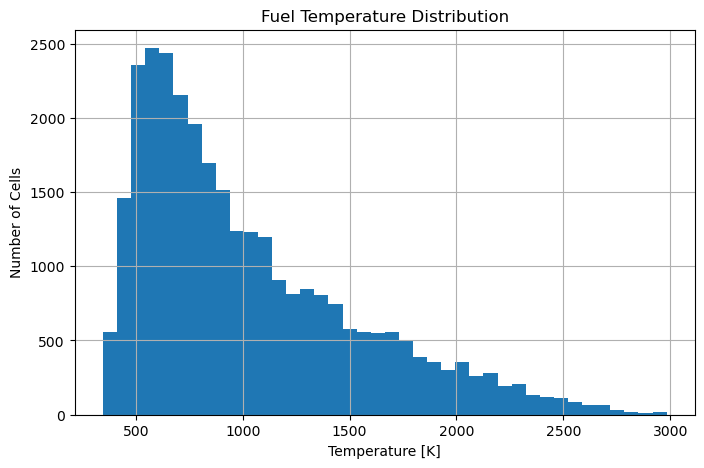

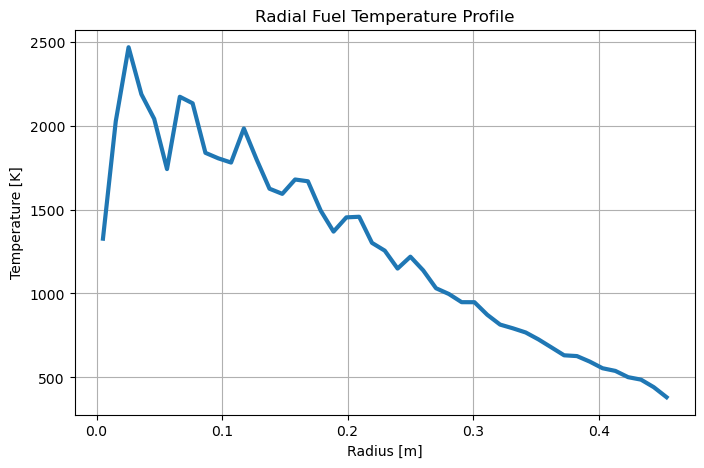

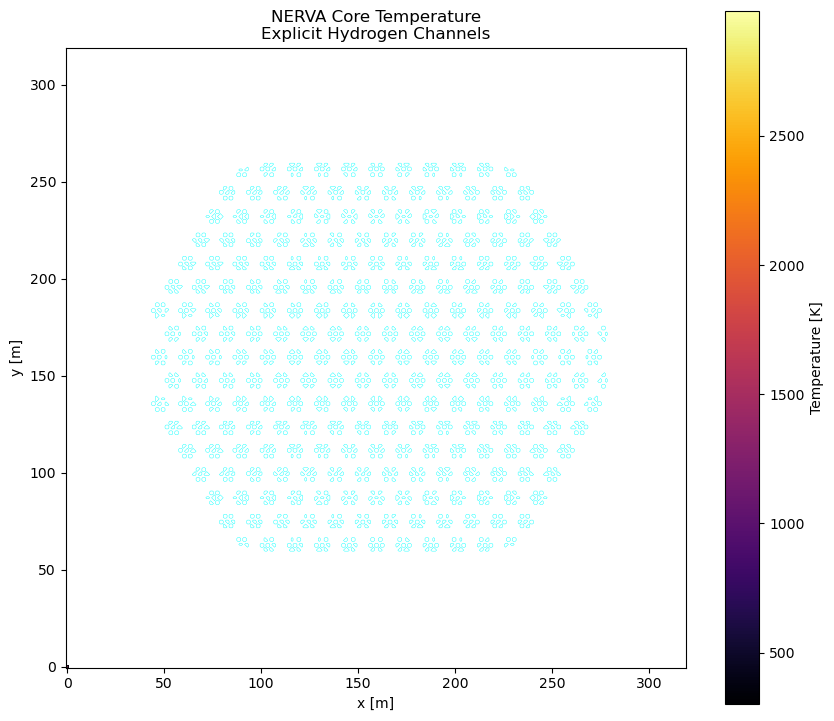


Generating MP4 animation...
MP4 saved:
NERVA_Hexagonal_Core.mp4

 NERVA NUCLEAR THERMAL ROCKET PERFORMANCE REPORT

Thermal Power             :     518.48 MW
Power Density             :    1223.69 MW/m³

Average Fuel Temperature  :     1026.3 K
Maximum Fuel Temperature  :     2983.0 K

H₂ Inlet Temperature      :      300.0 K
H₂ Exit Temperature       :     2314.3 K

Hydrogen Mass Flow        :      18.00 kg/s

Exhaust Velocity          :     8173.7 m/s
Specific Impulse          :      833.5 s
Thrust                    :      147.1 kN


Historical NERVA Reference:
--------------------------------------
Thermal Power   : 1000-5000 MW
Fuel Temp       : 2200-2800 K
Isp             : 800-950 s
Thrust          : 200-1100 kN
--------------------------------------

Simulation Finished Successfully.


In [2]:
# ================================================================
# NUCLEAR THERMAL ROCKET (NERVA)
# PART 2 OF 2
#
# Engineering Performance Analysis
#
# Features:
# - Thermal Power Calculation
# - Hydrogen Outlet Temperature
# - Exhaust Velocity
# - Thrust Estimation
# - Specific Impulse
# - Radial Temperature Profile
# - Temperature Histogram
# - MP4 Animation Export
# - Final Engineering Report
#
# ================================================================

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import (
    FuncAnimation,
    FFMpegWriter
)

# ================================================================
# HYDROGEN PROPELLANT PARAMETERS
# ================================================================

mdot = 18.0
# kg/s

cp_H2 = 14300.0
# J/(kg K)

gamma = 1.40

R_H2 = 4124.0
# J/(kg K)

g0 = 9.80665

# ================================================================
# THERMAL POWER
# ================================================================

cell_volume = dx * dy * 1.0

thermal_power = np.sum(
    Q[fuel_mask]
) * cell_volume

thermal_power_MW = thermal_power/1e6

# ================================================================
# ESTIMATE HYDROGEN OUTLET TEMPERATURE
# ================================================================

fuel_temperature_average = np.mean(
    T[fuel_mask]
)

fuel_temperature_max = np.max(
    T[fuel_mask]
)

# ------------------------------------------------
# Energy balance
# ------------------------------------------------

deltaT_H2 = (
    thermal_power
    /
    (mdot*cp_H2)
)

T_exit = Tinlet + deltaT_H2

# realistic cap

T_exit = min(
    T_exit,
    2900.0
)

# ================================================================
# EXHAUST VELOCITY
# ================================================================

ve = np.sqrt(

    (
        2.0*gamma
        /
        (gamma-1.0)
    )

    *

    R_H2

    *

    T_exit

)

# ================================================================
# SPECIFIC IMPULSE
# ================================================================

Isp = ve/g0

# ================================================================
# THRUST
# ================================================================

thrust = mdot*ve

thrust_kN = thrust/1000.0

# ================================================================
# CORE POWER DENSITY
# ================================================================

core_volume = np.sum(
    fuel_mask
) * cell_volume

power_density = (
    thermal_power
    /
    core_volume
)

# ================================================================
# TEMPERATURE HISTOGRAM
# ================================================================

plt.figure(figsize=(8,5))

plt.hist(
    T[fuel_mask],
    bins=40
)

plt.xlabel(
    'Temperature [K]'
)

plt.ylabel(
    'Number of Cells'
)

plt.title(
    'Fuel Temperature Distribution'
)

plt.grid()

plt.show()

# ================================================================
# RADIAL TEMPERATURE PROFILE
# ================================================================

R = np.sqrt(
    X**2 + Y**2
)

rbins = np.linspace(
    0,
    0.50,
    50
)

rtemp = []

for i in range(len(rbins)-1):

    mask = (

        (R >= rbins[i])
        &
        (R < rbins[i+1])
        &
        fuel_mask

    )

    if np.sum(mask) > 0:

        rtemp.append(
            np.mean(T[mask])
        )

    else:

        rtemp.append(
            np.nan
        )

rmid = 0.5*(
    rbins[:-1]
    +
    rbins[1:]
)

plt.figure(figsize=(8,5))

plt.plot(
    rmid,
    rtemp,
    linewidth=3
)

plt.xlabel(
    'Radius [m]'
)

plt.ylabel(
    'Temperature [K]'
)

plt.title(
    'Radial Fuel Temperature Profile'
)

plt.grid()

plt.show()

# ================================================================
# FINAL TEMPERATURE MAP
# ================================================================

plt.figure(figsize=(10,9))

plt.imshow(
    T,
    origin='lower',
    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],
    cmap='inferno'
)

plt.colorbar(
    label='Temperature [K]'
)

plt.contour(
    channel_mask,
    levels=[0.5],
    colors='cyan',
    linewidths=0.3
)

plt.title(
    'NERVA Core Temperature\n'
    'Explicit Hydrogen Channels'
)

plt.xlabel('x [m]')
plt.ylabel('y [m]')

plt.show()

# ================================================================
# MP4 ANIMATION
# ================================================================

print()
print("Generating MP4 animation...")

vmin = min(
    np.min(s)
    for s in snapshots
)

vmax = max(
    np.max(s)
    for s in snapshots
)

fig, ax = plt.subplots(
    figsize=(9,8)
)

im = ax.imshow(

    snapshots[0],

    origin='lower',

    extent=[
        x.min(),
        x.max(),
        y.min(),
        y.max()
    ],

    cmap='inferno',

    vmin=vmin,
    vmax=vmax,

    animated=True

)

cbar = plt.colorbar(im)

cbar.set_label(
    'Temperature [K]'
)

ax.set_xlabel(
    'x [m]'
)

ax.set_ylabel(
    'y [m]'
)

def update(frame):

    im.set_array(
        snapshots[frame]
    )

    ax.set_title(

        'NERVA Core Heat-Up\n'
        f'Frame {frame+1}/{len(snapshots)}'

    )

    return [im]

ani = FuncAnimation(

    fig,

    update,

    frames=len(snapshots),

    interval=50,

    blit=True

)

writer = FFMpegWriter(

    fps=20,

    bitrate=4000,

    metadata={
        "artist":"ChatGPT"
    }

)

ani.save(

    "NERVA_Hexagonal_Core.mp4",

    writer=writer,

    dpi=180

)

plt.close()

print(
    "MP4 saved:"
)

print(
    "NERVA_Hexagonal_Core.mp4"
)

# ================================================================
# PERFORMANCE SUMMARY
# ================================================================

print()
print("="*65)
print(" NERVA NUCLEAR THERMAL ROCKET PERFORMANCE REPORT")
print("="*65)

print()

print(
    f"Thermal Power             : {thermal_power_MW:10.2f} MW"
)

print(
    f"Power Density             : {power_density/1e6:10.2f} MW/m³"
)

print()

print(
    f"Average Fuel Temperature  : {fuel_temperature_average:10.1f} K"
)

print(
    f"Maximum Fuel Temperature  : {fuel_temperature_max:10.1f} K"
)

print()

print(
    f"H₂ Inlet Temperature      : {Tinlet:10.1f} K"
)

print(
    f"H₂ Exit Temperature       : {T_exit:10.1f} K"
)

print()

print(
    f"Hydrogen Mass Flow        : {mdot:10.2f} kg/s"
)

print()

print(
    f"Exhaust Velocity          : {ve:10.1f} m/s"
)

print(
    f"Specific Impulse          : {Isp:10.1f} s"
)

print(
    f"Thrust                    : {thrust_kN:10.1f} kN"
)

print()
print("="*65)

# ================================================================
# COMPARISON WITH HISTORICAL NERVA
# ================================================================

print()
print("Historical NERVA Reference:")
print("--------------------------------------")
print("Thermal Power   : 1000-5000 MW")
print("Fuel Temp       : 2200-2800 K")
print("Isp             : 800-950 s")
print("Thrust          : 200-1100 kN")
print("--------------------------------------")

print()
print("Simulation Finished Successfully.")